In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import Galactic, ICRS
from astropy import units as u
from modules.vr_opt import VrOpt
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import MinMaxScaler

import time
from sklearn.cluster import KMeans

import seaborn as sns

import plotly.graph_objs as go
import matplotlib.colors as mcolors

from scipy.spatial import KDTree

import random

from scipy.sparse import lil_matrix

from sklearn.neighbors import NearestNeighbors, KernelDensity
from matplotlib.lines import Line2D

import nbimporter
import visualisations

In [2]:
alphas = [0.9, 0.9, 0.3]
colors = ['tab:red', 'tab:blue', 'tab:grey']
zorders = [1, 1, 0]
log = True

# Create 6D Gaussian data
n = 1000 #1000
X_bg = (np.random.rand(n*5, 6) - 0.5) * 50

mu = np.array([-5, 5, 5, 5, -5, 5])
c_xx = c_yy = 20
c_xy = 15
c_zz = 3
c_uvw = 1
cov = np.diag([c_xx, c_yy, c_zz, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy
# Add signal
X_sig_1 = np.random.multivariate_normal(mu, cov, n//2)

# Second cluster
mu_2 = np.array([5, -5, -5, -5, 5, -5])
c_xx_2 = c_yy = 20
c_xy_2 = -15
c_zz_2 = 3
cov = np.diag([c_xx_2, c_yy, c_zz_2, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy_2
X_sig_2 = np.random.multivariate_normal(mu_2, cov, n//2)

X = np.concatenate([X_bg, X_sig_1, X_sig_2], axis=0)
labels = np.concatenate([np.zeros(n*5), np.ones(n//2), np.ones(n//2)*2])

df = pd.DataFrame(X, columns=['x', 'y', 'z', 'vx', 'vy', 'vz'])
# Transform to spherical coordinates
gal_coords = Galactic(
    u=df.x.values * u.pc,
    v=df.y.values * u.pc,
    w=df.z.values * u.pc,
    # velocities UVW
    U=df.vx.values * u.km / u.s,
    V=df.vy.values * u.km / u.s,
    W=df.vz.values * u.km / u.s,
    representation_type="cartesian",
    # Velocity representation
    differential_type="cartesian",
)
# transform to ICRS
icrs_coords = gal_coords.transform_to(ICRS())
icrs_coords.representation_type = "spherical"

ra = icrs_coords.ra.value
dec = icrs_coords.dec.value
dist = icrs_coords.distance.value
pmra = icrs_coords.pm_ra.value * np.cos(np.deg2rad(dec))
pmdec = icrs_coords.pm_dec.value
rv_calc = icrs_coords.radial_velocity.value

df['ra'] = ra
df['dec'] = dec
df['dist'] = dist
df['pmra'] = pmra
df['pmdec'] = pmdec
df['radial_velocity'] = rv_calc

df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74

idx_cluster_1 = np.where(labels==1)[0]
idx_cluster_2 = np.where(labels==2)[0]
idx_bg = np.where(labels==0)[0]

In [3]:
est = VrOpt(ra, dec, pmra, pmdec, dist)

# # Lower triangular matrix indices
a, b = np.tril_indices(len(X), -1)
_, _, delta_v = est.vr_opt(a, b)

# Create pairwise distance matrix with delta_v entries
dist_v_opt = np.zeros((len(X), len(X)))
dist_v_opt[a, b] = delta_v
dist_v_opt[b, a] = delta_v

# Compute semi-cohesion metric G
G = np.copy(dist_v_opt)
G = np.full_like(G, np.sum(G, axis=0)/len(G)) + np.full_like(G, np.sum(G, axis=0)/len(G)).T - np.sum(G)/len(G)**2 - G

In [4]:
def softmax_clustering_optimized_iphd(Gamma, K, theta=0.001, epsilon=0.0001, max_iter=250, initial_partition=None):

    start_time = time.time()

    # Set g[i,i] = 0 for all i
    np.fill_diagonal(Gamma, 0)
    n = Gamma.shape[0]

    np.random.seed(42)

    # Use the initial partition if provided, otherwise initialize randomly
    if initial_partition is not None:
        p_i = initial_partition
    else:
        p_i = np.random.dirichlet(np.ones(K), size=n)

    z = np.zeros((n, K))  # for covariance

    for iteration in range(max_iter):
        # Compute covaraince (z)for all points and clusters
        
        z = Gamma @ p_i 
        # Stabilize softmax computation
        z_max = np.max(theta * z, axis=1, keepdims=True) 
        p_t = np.exp(theta * z - z_max) * p_i  

        #p_t = np.exp(theta * z) * p_i  # Softmax function
        p_i = p_t / (np.sum(p_t, axis=1, keepdims=True) + 1e-10)  # Update probability uisng softmax function and normalize it (it must sum to 1)

        theta += epsilon

         # If pi changes insignificantly, stop
        if iteration > 0 and np.allclose(p_i, prev_pi, atol=1e-6):
            break

        prev_pi = p_i.copy()
        
    execution_time = time.time() - start_time
    print(f'Execution time (softmax): {int(execution_time // 60)} minutes, {int(execution_time % 60)} seconds and {int((execution_time % 1) * 1000)} ms')
    print(f'Number of iterations (softmax): {iteration + 1}')

    return p_i, z

In [5]:
K = 6
p_i_opt, z_opt = softmax_clustering_optimized_iphd(G, K)

Execution time (softmax): 0 minutes, 6 seconds and 805 ms
Number of iterations (softmax): 250


In [6]:
# get clusters from probability
def get_clusters(p_i):

    cluster_labels = np.argmax(p_i, axis=1)
    _, relabeled_clusters = np.unique(cluster_labels, return_inverse=True)
    
    return relabeled_clusters


In [7]:
# get cluster labels and number of clusters
labels_softmax = get_clusters(p_i_opt) 

In [8]:
def extract_leaf_nodes(kd_node, point_indices, points, node_indices, point_in_node):
  
    if isinstance(kd_node, KDTree.leafnode):
        unique_indices = np.setdiff1d(point_indices, list(point_in_node.keys()), assume_unique=True)
        if len(unique_indices) > 0:
            node_indices.append(unique_indices)
            point_in_node.update({idx: len(node_indices) - 1 for idx in unique_indices})
    else:
        split_dim = kd_node.split_dim
        split_val = kd_node.split
        left_indices = point_indices[points[point_indices, split_dim] <= split_val]
        right_indices = point_indices[points[point_indices, split_dim] > split_val]

        extract_leaf_nodes(kd_node.less, left_indices, points, node_indices, point_in_node)
        extract_leaf_nodes(kd_node.greater, right_indices, points, node_indices, point_in_node)
        
def prepare_kdtree(df, leafsize=300):
    points = df[['x', 'y', 'z']].values
    kd_tree = KDTree(points, leafsize=leafsize)

    node_indices = []
    point_in_node = {}
    extract_leaf_nodes(kd_tree.tree, np.arange(len(points)), points, node_indices, point_in_node)
    return kd_tree, node_indices, point_in_node

# Functions for q measure visualization

In [9]:
def plot_q_measure_histogram(clusters, G, true_labels, background_label=0, weights=None, shared_points_threshold=15):

    q_values = []
    filtered_q_values = []
    merge_decisions = []  # True for merge (green), false for no merge (red)

    # Compute q measures
    for i, cluster1 in enumerate(clusters):
        for j, cluster2 in enumerate(clusters):
            if i > j and cluster1 and cluster2:  # Only lower triangula
                cluster1_indices = np.array(list(cluster1))
                cluster2_indices = np.array(list(cluster2))

                G_sub = G[np.ix_(cluster1_indices, cluster2_indices)]

                # Compute q value
                if weights is not None:
                    weights1 = np.array([weights[idx] for idx in cluster1_indices]).reshape(-1, 1)
                    weights2 = np.array([weights[idx] for idx in cluster2_indices]).reshape(1, -1)
                    q_value = np.sum(G_sub * weights1 * weights2)
                else:
                    q_value = np.sum(G_sub)

                q_values.append(q_value)

                # Check if clusters share enough points of the same label
                labels1 = true_labels[cluster1_indices]
                labels2 = true_labels[cluster2_indices]

                # Exclude background points
                labels1 = labels1[labels1 != background_label]
                labels2 = labels2[labels2 != background_label]

                shared_labels = set(labels1).intersection(labels2)

                should_merge = False 
                for label in shared_labels:
                    count1 = np.sum(labels1 == label)
                    count2 = np.sum(labels2 == label)
                    if count1 >= shared_points_threshold and count2 >= shared_points_threshold:
                        filtered_q_values.append(q_value)
                        should_merge = True
                        break

                merge_decisions.append(should_merge)

   # First plot
    plt.figure(figsize=(10, 6))
    plt.hist(q_values, bins=50, histtype='step', color="gray", linewidth=1.5, label="All Q Values")
    plt.yscale('log') 
    plt.title("Q Measure Distribution (Logarithmic Scale)")
    plt.xlabel("Q Measure")
    plt.ylabel("Frequency (log scale)")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    if filtered_q_values:
        plt.hist(filtered_q_values, bins=50, color="orange", alpha=0.7, edgecolor="black",
                 label=f"Q Values (Shared Points ≥ {shared_points_threshold})")

    plt.legend()
    plt.show()

    # Second plot
    merge_q_values = [q for q, merge in zip(q_values, merge_decisions) if merge]
    no_merge_q_values = [q for q, merge in zip(q_values, merge_decisions) if not merge]

    plt.figure(figsize=(10, 6))

    # Green: merge true
    if merge_q_values:
        plt.hist(merge_q_values, bins=50, color="green", alpha=0.5, edgecolor="black",
                 label="Merge: True (Green)")

    # Red: merge false 
    if no_merge_q_values:
        plt.hist(no_merge_q_values, bins=50, color="red", alpha=0.5, edgecolor="black",
                 label="Merge: False (Red)")

    plt.yscale('log') 
    plt.title("Q Measure Decision Histogram (Logarithmic Scale and Transparency)")
    plt.xlabel("Q Measure")
    plt.ylabel("Frequency (log scale)")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()
    plt.show()


In [10]:
def plot_q_measure_matrix(clusters, G, true_labels, background_label=0, weights=None, shared_points_threshold=15):

    cluster_count = len(clusters)
    q_matrix = np.zeros((cluster_count, cluster_count))
    dot_positions = []

    # Compute q measures
    for i, cluster1 in enumerate(clusters):
        for j, cluster2 in enumerate(clusters):
            if i > j and cluster1 and cluster2:  # Lower triangular 
                cluster1_indices = np.array(list(cluster1))
                cluster2_indices = np.array(list(cluster2))

                G_sub = G[np.ix_(cluster1_indices, cluster2_indices)]

                # Compute q value
                if weights is not None:
                    weights1 = np.array([weights[idx] for idx in cluster1_indices]).reshape(-1, 1)
                    weights2 = np.array([weights[idx] for idx in cluster2_indices]).reshape(1, -1)
                    q_value = np.sum(G_sub * weights1 * weights2)
                else:
                    q_value = np.sum(G_sub)

                q_matrix[i, j] = q_value

                # Check if clusters share enough points of the same label
                labels1 = true_labels[cluster1_indices]
                labels2 = true_labels[cluster2_indices]

                # Exclude background points
                labels1 = labels1[labels1 != background_label]
                labels2 = labels2[labels2 != background_label]

                shared_labels = set(labels1).intersection(labels2)

                for label in shared_labels:
                    count1 = np.sum(labels1 == label)
                    count2 = np.sum(labels2 == label)
                    if count1 >= shared_points_threshold and count2 >= shared_points_threshold:
                        # Append dot color based on q value
                        color = "green" if q_value > 0 else "orange"
                        dot_positions.append((i, j, color))

    # Mask upper triangle
    mask = np.triu(np.ones_like(q_matrix, dtype=bool))

    # Plot q measure matrix (heatmap)
    plt.figure(figsize=(24, 20))
    cmap = sns.diverging_palette(240, 10, as_cmap=True)
    ax = sns.heatmap(
        q_matrix, mask=mask, annot=False, fmt=".2f", cmap=cmap,
        cbar=True, linewidths=0.5, center=0
    )
    plt.title("Q Measure Matrix")
    plt.xlabel("Cluster Index")
    plt.ylabel("Cluster Index")

    
    ticks = np.arange(0, cluster_count, 3)
    ax.set_xticks(ticks + 0.5)
    ax.set_xticklabels(ticks, fontsize=8, rotation=90)
    ax.set_yticks(ticks + 0.5)
    ax.set_yticklabels(ticks, fontsize=8)

    # Add dots for specified positions
    for i, j, color in dot_positions:
        ax.add_patch(plt.Circle((j + 0.5, i + 0.5), 0.1, color=color, lw=1))

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=f"Shared Points ≥ {shared_points_threshold}, q > 0",
               markerfacecolor='green', markersize=6),
        Line2D([0], [0], marker='o', color='w', label=f"Shared Points ≥ {shared_points_threshold}, q < 0",
               markerfacecolor='orange', markersize=6)
    ]
    plt.legend(handles=legend_elements, loc='upper right', title="Legend")

    plt.show()

# Initial algorithm with KDTree, softmax

In [11]:
class TreeNode:
  
    def __init__(self, kd_node, point_indices):
        self.kd_node = kd_node
        self.point_indices = point_indices
        self.left = None
        self.right = None
        self.cluster = set(point_indices)

# Traverse kdtree and extract only its leaf nodes
def extract_leaf_nodes(kd_node, point_indices, points, node_indices, point_in_node):
  
    if isinstance(kd_node, KDTree.leafnode):
        unique_indices = np.setdiff1d(point_indices, list(point_in_node.keys()), assume_unique=True)
        if len(unique_indices) > 0:
            node_indices.append(unique_indices)
            point_in_node.update({idx: len(node_indices) - 1 for idx in unique_indices})
    else:
        split_dim = kd_node.split_dim
        split_val = kd_node.split
        left_indices = point_indices[points[point_indices, split_dim] <= split_val]
        right_indices = point_indices[points[point_indices, split_dim] > split_val]

        extract_leaf_nodes(kd_node.less, left_indices, points, node_indices, point_in_node)
        extract_leaf_nodes(kd_node.greater, right_indices, points, node_indices, point_in_node)

# Compute semi-cohesion G matrix
def compute_g_matrix(dist_matrix):

    G = np.full_like(dist_matrix, np.sum(dist_matrix, axis=0)/len(dist_matrix)) + np.full_like(dist_matrix, np.sum(dist_matrix, axis=0)/len(dist_matrix)).T - np.sum(dist_matrix)/len(dist_matrix)**2 - dist_matrix
    return G


# Run softmax clustering for each leaf node
def softmax_clustering_leaves(node_indices, G, K, softmax_clustering_func):
  
    cluster_results = []
    for i, indices in enumerate(node_indices):
        subset_G = G[np.ix_(indices, indices)]
        p_i, z = softmax_clustering_func(subset_G, K)
        cluster_labels_node = get_clusters(p_i)

        # Just for testing
        num_clusters = len(np.unique(cluster_labels_node))
        print(f"Leaf Node {i + 1}:")
        print(f" - Number of clusters: {num_clusters}")
        print(f" - Number of points: {len(indices)}")

        cluster_results.append((cluster_labels_node, indices))
    return cluster_results

# Correlation measure q for merging clusters
def compute_q(S1, S2, G):
   
    return np.sum(G[np.ix_(list(S1), list(S2))])

def hierarchical_agglomerative_merging(clusters, G):
   
    cluster_count = len(clusters)
    q_matrix = lil_matrix((cluster_count, cluster_count), dtype=np.float64)

    # q-matrix
    for i, cluster1 in enumerate(clusters):
        for j, cluster2 in enumerate(clusters[i + 1:], start=i + 1):
            q_matrix[i, j] = compute_q(cluster1, cluster2, G)

    while len(clusters) > 1:
        # Convert to CSR for efficient matrix operations
        q_csr = q_matrix.tocsr()
        max_index = q_csr.argmax()
        i, j = divmod(max_index, q_matrix.shape[1])

        if q_matrix[i, j] <= 0:
            print("No positive q values, stopping merging.")
            break

        print(f"Merging cluster {i} with cluster {j}, q = {q_matrix[i, j]}")

        # Merge clusters
        clusters[i] = clusters[i].union(clusters[j])
        clusters[j] = set()

        # Update q-matrix for merged cluster
        for k, cluster in enumerate(clusters):
            if cluster and k != i and k != j:
                q_matrix[i, k] = compute_q(clusters[i], cluster, G)
                q_matrix[k, i] = q_matrix[i, k]

        # Deactivate merged clusters
        q_matrix[j, :] = 0
        q_matrix[:, j] = 0

    return [cluster for cluster in clusters if cluster]


def tree_merging_clustering(df, dist_matrix, K, node_indices, point_in_node, softmax_clustering_func = softmax_clustering_optimized_iphd, true_labels = labels):
   
    print(f"Total number of points assigned to leaf nodes: {len(point_in_node)}")
    # G matrix
    G = compute_g_matrix(dist_matrix)

    # Softmax clustering for each leaf node
    cluster_results_softmax = softmax_clustering_leaves(node_indices, G, K, softmax_clustering_func)
    print(cluster_results_softmax)

    # Get initial clusters for merging
    clusters = [
        {idx for idx, lbl in zip(indices, labels) if lbl == label}
        for labels, indices in cluster_results_softmax
        for label in np.unique(labels)
    ]

    plot_q_measure_histogram(
    clusters=clusters,
    G=G,
    true_labels=true_labels,
    background_label=0,
    weights=None,  # No weights
    shared_points_threshold=15
)

    # Hierarchical agglomerative merging
    final_clusters = hierarchical_agglomerative_merging(clusters, G)

    total_points_final = len(set().union(*final_clusters))
    print(f"Original number of points: {len(df)}")
    print(f"Total unique points in final clusters: {total_points_final}")

    return cluster_results_softmax, final_clusters


def prepare_kdtree(df, leafsize=300):
    points = df[['x', 'y', 'z']].values
    kd_tree = KDTree(points, leafsize=leafsize)

    node_indices = []
    point_in_node = {}
    extract_leaf_nodes(kd_tree.tree, np.arange(len(points)), points, node_indices, point_in_node)
    return kd_tree, node_indices, point_in_node

Total number of points assigned to leaf nodes: 6000


Execution time (softmax): 0 minutes, 0 seconds and 9 ms
Number of iterations (softmax): 156
Leaf Node 1:
 - Number of clusters: 4
 - Number of points: 188
Execution time (softmax): 0 minutes, 0 seconds and 8 ms
Number of iterations (softmax): 138
Leaf Node 2:
 - Number of clusters: 3
 - Number of points: 188
Execution time (softmax): 0 minutes, 0 seconds and 10 ms
Number of iterations (softmax): 171
Leaf Node 3:
 - Number of clusters: 3
 - Number of points: 188
Execution time (softmax): 0 minutes, 0 seconds and 11 ms
Number of iterations (softmax): 184
Leaf Node 4:
 - Number of clusters: 3
 - Number of points: 187
Execution time (softmax): 0 minutes, 0 seconds and 15 ms
Number of iterations (softmax): 250
Leaf Node 5:
 - Number of clusters: 3
 - Number of points: 189
Execution time (softmax): 0 minutes, 0 seconds and 13 ms
Number of iterations (softmax): 220
Leaf Node 6:
 - Number of clusters: 4
 - Number of points: 187
Execution time (softmax): 0 minutes, 0 seconds and 10 ms
Number of

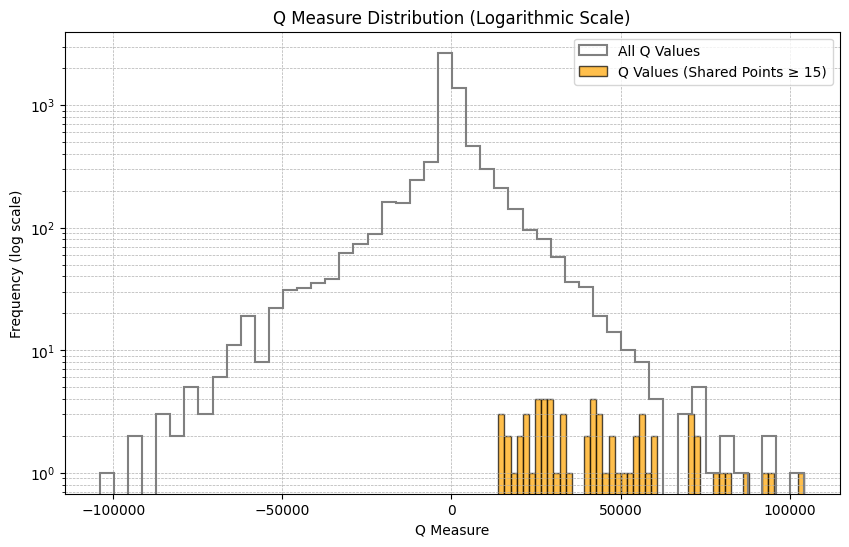

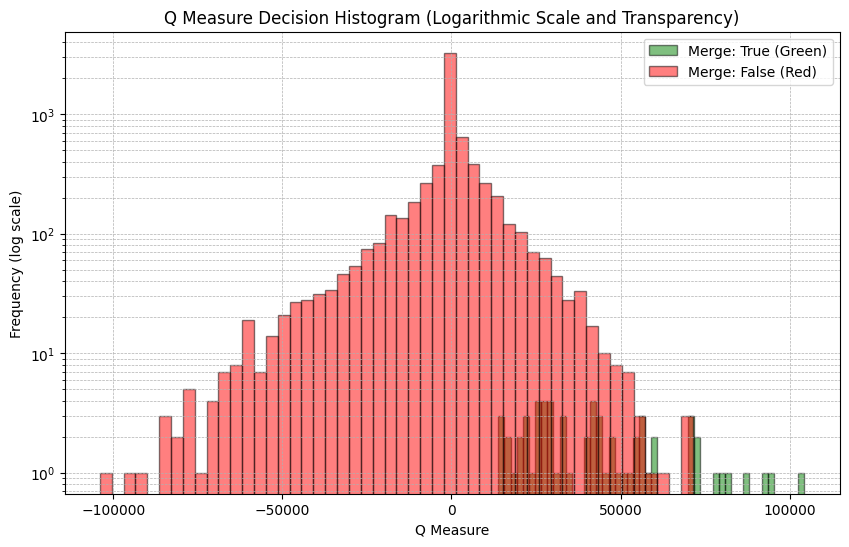

Merging cluster 10 with cluster 35, q = 104364.99233408224
Merging cluster 10 with cluster 47, q = 163647.8410789124
Merging cluster 10 with cluster 28, q = 191672.59499623382
Merging cluster 10 with cluster 37, q = 214396.5906703197
Merging cluster 10 with cluster 91, q = 250157.54075031375
Merging cluster 10 with cluster 16, q = 219470.30461860026
Merging cluster 4 with cluster 10, q = 224957.58916808653
Merging cluster 4 with cluster 88, q = 238558.93494610157
Merging cluster 4 with cluster 26, q = 271735.83360293607
Merging cluster 4 with cluster 109, q = 304103.655277021
Merging cluster 4 with cluster 15, q = 295173.8085200811
Merging cluster 4 with cluster 111, q = 330000.0821488882
Merging cluster 3 with cluster 4, q = 338811.7782994086
Merging cluster 3 with cluster 98, q = 335001.6873230927
Merging cluster 3 with cluster 7, q = 344228.17229144764
Merging cluster 3 with cluster 41, q = 324417.98464423884
Merging cluster 3 with cluster 117, q = 307191.7632628712
Merging cluster 

In [12]:
K = 6
leaf_size = 300 

kd_tree, node_indices, point_in_node = prepare_kdtree(df, leafsize=300)
cluster_results_softmax, final_clusters = tree_merging_clustering(df, dist_v_opt, K, node_indices, point_in_node)

# Using weights for q measuere

In [13]:
# Weights influencing q measure
def hierarchical_agglomerative_merging_with_weights(clusters, G, weights):

    cluster_count = len(clusters)
    q_matrix = lil_matrix((cluster_count, cluster_count), dtype=np.float64)

    # Initialize q-matrix with weighted q values
    for i, cluster1 in enumerate(clusters):
        for j, cluster2 in enumerate(clusters[i + 1:], start=i + 1):
            if cluster1 and cluster2:  # Skip invalid clusters
                cluster1_indices = np.array(list(cluster1))
                cluster2_indices = np.array(list(cluster2))

                G_sub = G[np.ix_(cluster1_indices, cluster2_indices)]
                weights1 = np.array(weights[i])[:len(cluster1_indices)].reshape(-1, 1)
                weights2 = np.array(weights[j])[:len(cluster2_indices)].reshape(1, -1)

                if G_sub.shape == (weights1.shape[0], weights2.shape[1]):
                    q_matrix[i, j] = np.sum(G_sub * weights1 * weights2)

    while len([c for c in clusters if len(c) > 0]) > 1:
        q_csr = q_matrix.tocsr()
        max_index = q_csr.argmax()
        i, j = divmod(max_index, q_matrix.shape[1])

        if q_matrix[i, j] <= 0:
            print("No positive Q values, stopping merging.")
            break

        print(f"Merging cluster {i} with cluster {j}, Q = {q_matrix[i, j]}")

        # Merge clusters
        clusters[i] = clusters[i].union(clusters[j])

        # Combine weights 
        weights[i] = np.concatenate((weights[i][:len(clusters[i]) - len(clusters[j])], weights[j][:len(clusters[j])]))

        # Override merged cluster
        clusters[j] = set()
        weights[j] = []

        # Update q-matrix for merged cluster
        for k, cluster in enumerate(clusters):
            if cluster and k != i and k != j:
                cluster1_indices = np.array(list(clusters[i]))
                cluster2_indices = np.array(list(cluster))

                G_sub = G[np.ix_(cluster1_indices, cluster2_indices)]
                weights1 = np.array(weights[i])[:len(cluster1_indices)].reshape(-1, 1)
                weights2 = np.array(weights[k])[:len(cluster2_indices)].reshape(1, -1)

                if G_sub.shape == (weights1.shape[0], weights2.shape[1]):
                    q_matrix[i, k] = np.sum(G_sub * weights1 * weights2)
                    q_matrix[k, i] = q_matrix[i, k]

        # Clear q-matrix
        q_matrix[j, :] = 0
        q_matrix[:, j] = 0

    final_clusters = [cluster for cluster in clusters if len(cluster) > 0]
    return final_clusters

# Use denisty estimation to calculate weights 

In [14]:
def sigmoid(x, scale=1):
    return 1 / (1 + np.exp(-x / scale))

def density_estimation_per_leaf_with_labels(
df, node_indices, labels, cluster_colors, threshold, method="kde",
    bandwidth=0.5, min_neighbors=5, max_neighbors=50, color_option="clusters",
    single_color="tab:blue", plot_title=None, leaf_idx=None
):
 
    scaler = MinMaxScaler()
    points = df[['x', 'y', 'z']].values
    points_scaled = scaler.fit_transform(points)

    background_label = 0
    unique_labels = sorted(np.unique(labels))
    weights_per_leaf = []

    for idx, leaf_points_indices in enumerate(node_indices):
        leaf_points = points_scaled[leaf_points_indices]
        leaf_labels = labels[leaf_points_indices]

        # Skip leaves with too few points
        if len(leaf_points) < min_neighbors:
            print(f"Leaf {idx}: Not enough points for density estimation.")
            weights_per_leaf.append(np.ones(len(leaf_points_indices)))
            continue

        plt.figure(figsize=(10, 6))

        # Density estimation
        if method == "kde":
            kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth)
            kde.fit(leaf_points)
            rho = np.exp(kde.score_samples(leaf_points))
        elif method == "knn":
            # Adjust neighbors 
            n_neighbors = min(max_neighbors, len(leaf_points) - 1)
            n_neighbors = max(n_neighbors, min_neighbors)

            nbrs = NearestNeighbors(n_neighbors=n_neighbors)
            nbrs.fit(leaf_points)
            distances, _ = nbrs.kneighbors(leaf_points)
            d_k = distances[:, -1]
            rho = 1 / d_k

        # Normalize density values
        rho_normalized = (rho - rho.min()) / (rho.max() - rho.min())

        # Compute weights using sigmoid function
        weights = sigmoid(rho_normalized - threshold, scale=0.1)
        weights = (weights - weights.min()) / (weights.max() - weights.min())
        weights_per_leaf.append(weights)

        # Plot treshold
        base_counts, base_bins, _ = plt.hist(
            rho_normalized, bins=50, range=(0, 1), density=True, histtype="step",
            color="black", label="Base Density", linewidth=1.5
        )
        plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label="Threshold")

        # Background and cluster points
        background_mask = leaf_labels == background_label
        cluster_mask = leaf_labels != background_label

        # Background points
        background_rho = rho_normalized[background_mask]
        background_weights = np.ones_like(background_rho) * (base_counts.sum() / len(rho_normalized))
        plt.hist(
            background_rho, bins=base_bins, weights=background_weights, histtype="stepfilled",
            alpha=0.8, color=cluster_colors[-1], label="Background"
        )

        # Cluster points
        for label in unique_labels:
            if label == background_label:
                continue
            label_mask = leaf_labels == label
            label_rho = rho_normalized[label_mask]
            label_weights = np.ones_like(label_rho) * (base_counts.sum() / len(rho_normalized))

            plt.hist(
                label_rho, bins=base_bins, weights=label_weights, histtype="stepfilled",
                alpha=0.8, color=cluster_colors[int(label) - 1], label=f"Cluster {int(label)}"
            )

        title = f"Density Estimation for Leaf {leaf_idx if leaf_idx is not None else idx}"
        plt.title(plot_title if plot_title else title)
        plt.legend()
        plt.grid()
        plt.show()

    return weights_per_leaf


In [15]:
def tree_merging_clustering_with_weights(
    df, dist_matrix, K, node_indices, point_in_node, labels, cluster_colors, 
    threshold=0.5, method="kde", bandwidth=0.5, max_neighbors=50, min_neighbors=5, 
    color_option="clusters", single_color="tab:blue", option="before_softmax", 
    softmax_clustering_func=softmax_clustering_optimized_iphd
):
    G = compute_g_matrix(dist_matrix) 
    clusters = []  
    weights_global = np.zeros(len(df))  # weights for all points

    if option == "before_softmax":
        print("Density Estimation before softmax clustering")

        # Perform density estimation and calculate weights
        for leaf_idx, indices in enumerate(node_indices):
            leaf_points = df.iloc[indices]
            weights = density_estimation_per_leaf_with_labels(
                leaf_points, [np.arange(len(indices))], labels[indices], cluster_colors, 
                threshold, method, bandwidth, min_neighbors, max_neighbors, color_option,
                single_color, plot_title=None, leaf_idx=leaf_idx 
            )
            weights_global[indices] = weights  # Store weights globally

        # Perform softmax clustering after calculating weights
        for leaf_idx, indices in enumerate(node_indices):
            subset_G = G[np.ix_(indices, indices)]  # Extract G matrix for this leaf
            p_i, z = softmax_clustering_func(subset_G, K)
            cluster_labels_node = get_clusters(p_i)

            for cluster_id in np.unique(cluster_labels_node):
                cluster_indices = np.where(cluster_labels_node == cluster_id)[0]
                cluster_points = indices[cluster_indices]
                clusters.append(set(cluster_points))

        plot_q_measure_histogram(
            clusters=clusters,
            G=G,
            true_labels=labels,
            background_label=0,  
            weights=weights_global,  
            shared_points_threshold=15  
        )

        plot_q_measure_matrix(clusters, G, true_labels=labels, background_label=0, weights=weights_global)

    elif option == "after_softmax":
        print("Density estimation after softmax clustering")

        # Perform softmax clustering for each leaf node
        for leaf_idx, indices in enumerate(node_indices):
            subset_G = G[np.ix_(indices, indices)]  # Extract G matrix for this leaf
            p_i, z = softmax_clustering_func(subset_G, K)
            cluster_labels_node = get_clusters(p_i)

            # Density estimation for each cluster
            for cluster_id in np.unique(cluster_labels_node):
                cluster_indices = np.where(cluster_labels_node == cluster_id)[0]
                cluster_points = indices[cluster_indices]
                cluster_df = df.iloc[cluster_points]

                plot_title = f"Density Estimation for Leaf {leaf_idx}, Cluster {cluster_id}"
                weights = density_estimation_per_leaf_with_labels(
                    cluster_df, [np.arange(len(cluster_points))], labels[cluster_points],
                    cluster_colors, threshold, method, bandwidth, min_neighbors, max_neighbors,
                    color_option, single_color, plot_title=plot_title, leaf_idx=leaf_idx
                )

                clusters.append(set(cluster_points))
                weights_global[cluster_points] = weights

        
        plot_q_measure_histogram(
            clusters=clusters,
            G=G,
            true_labels=labels,
            background_label=0,  
            weights=weights_global,  
            shared_points_threshold=15  
        )
        plot_q_measure_matrix(clusters, G, true_labels=labels, background_label=0, weights=weights_global)

    else:
        raise ValueError("Option must be 'before_softmax' or 'after_softmax'.")

    # Convert global weights into per cluster weights
    weights_per_cluster = [np.array([weights_global[idx] for idx in cluster]) for cluster in clusters]

    print("Hierarchical agglomerative merging with weights")
    final_clusters = hierarchical_agglomerative_merging_with_weights(clusters, G, weights_per_cluster)

    print("Final clusters computed")
    return final_clusters


In [16]:
kd_tree, node_indices, point_in_node = prepare_kdtree(df, leafsize=300)

Density Estimation before softmax clustering


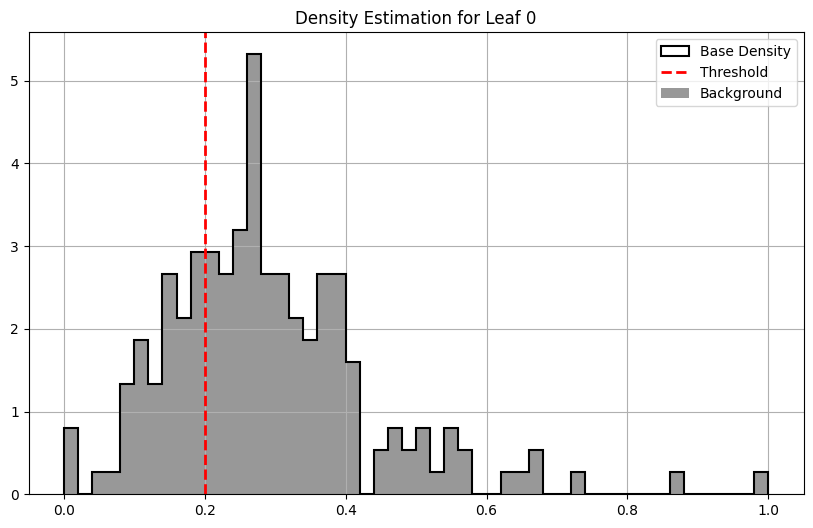

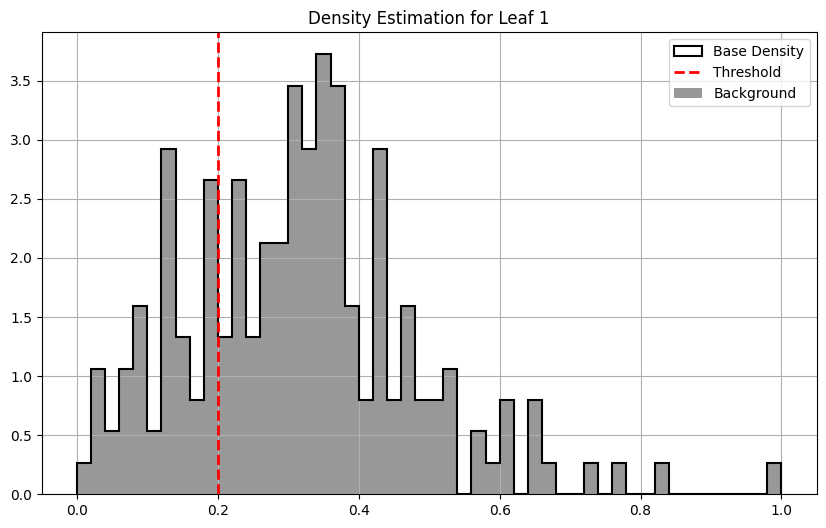

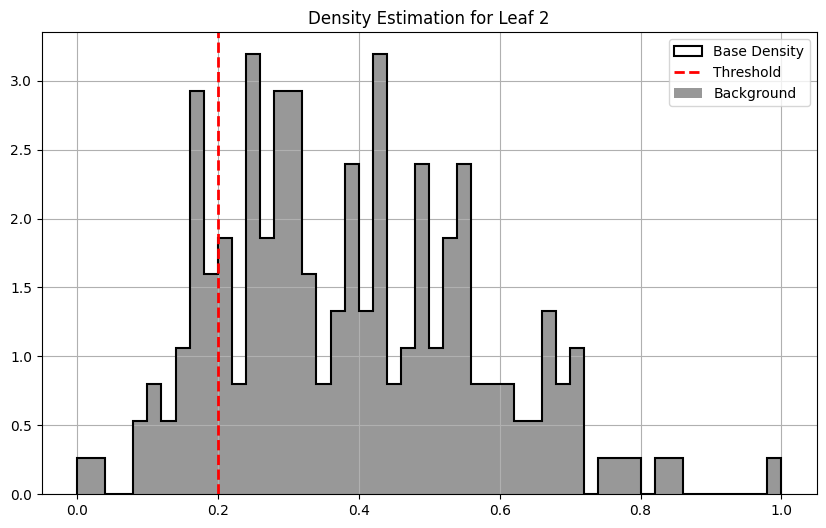

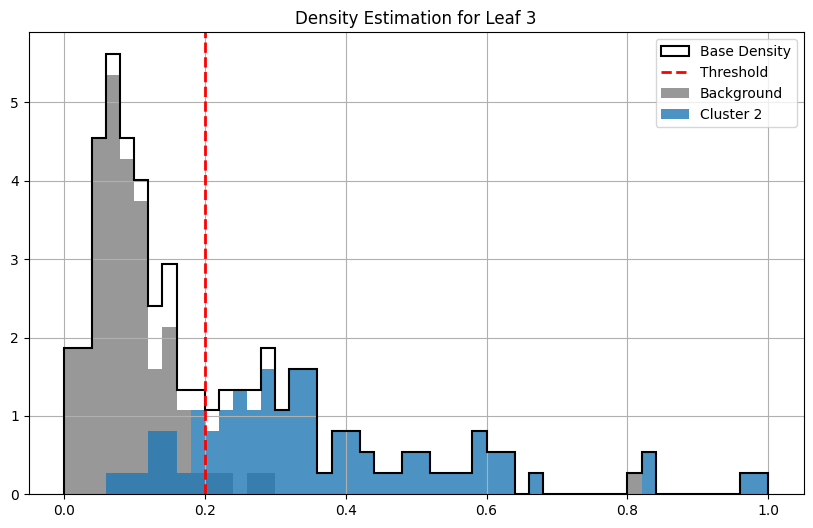

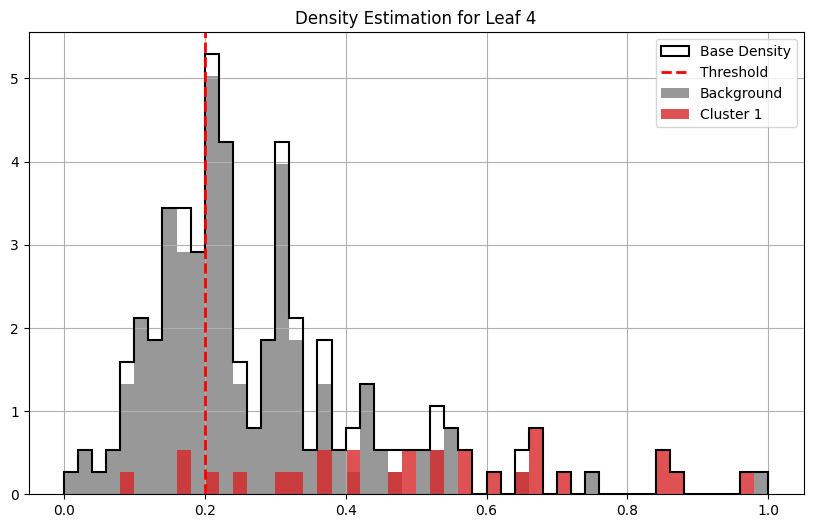

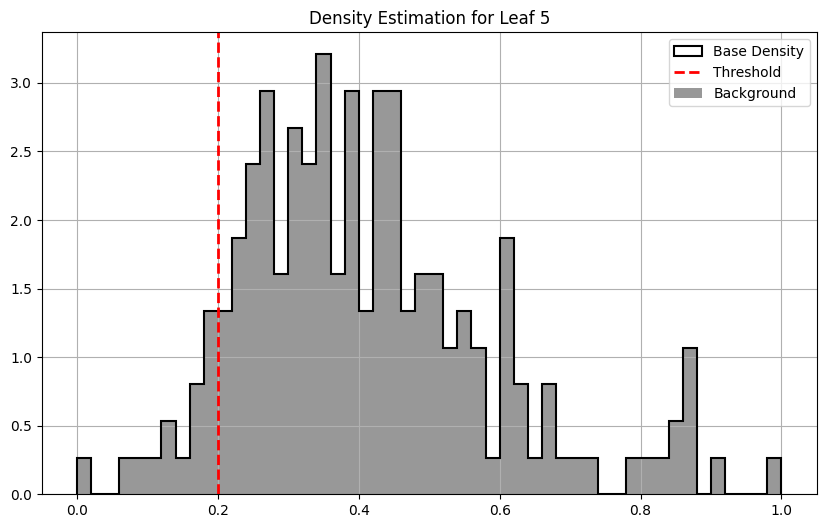

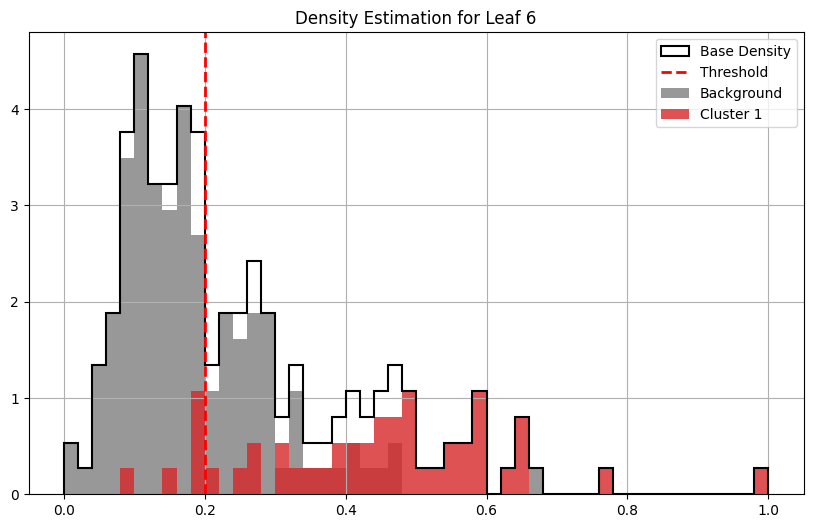

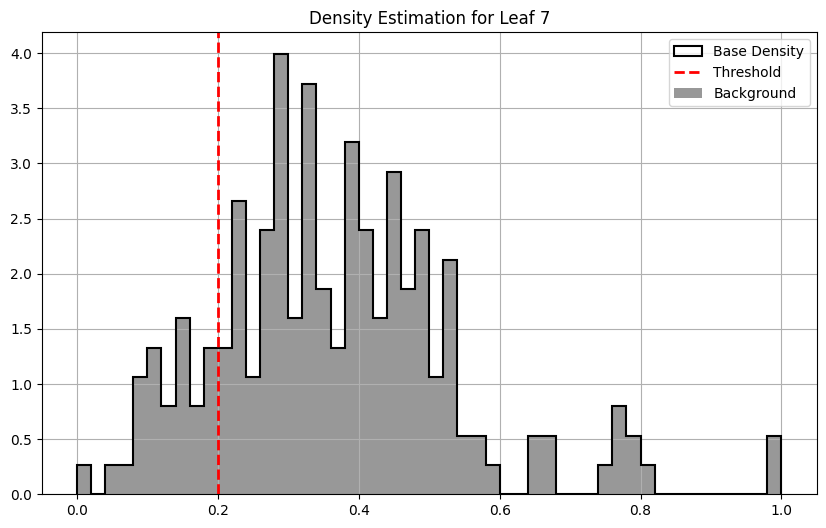

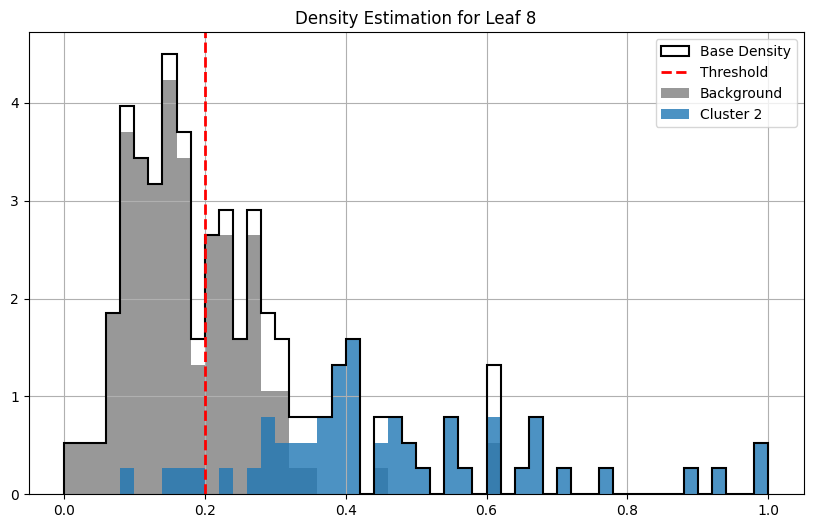

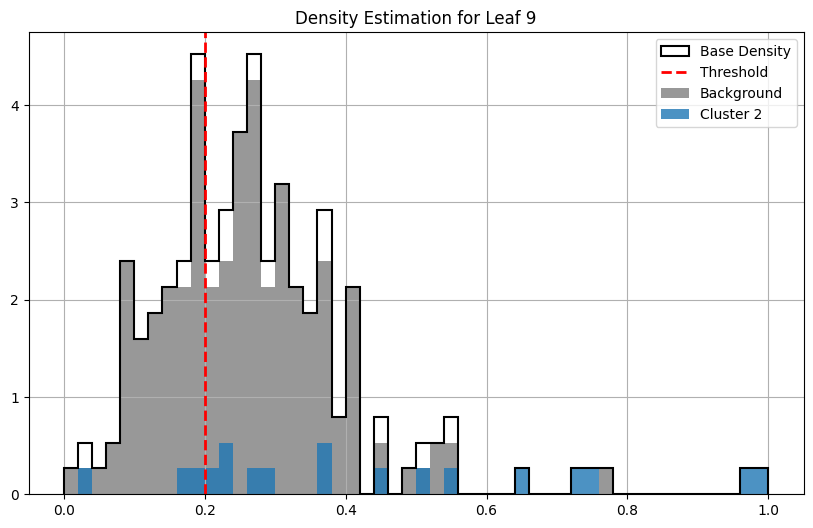

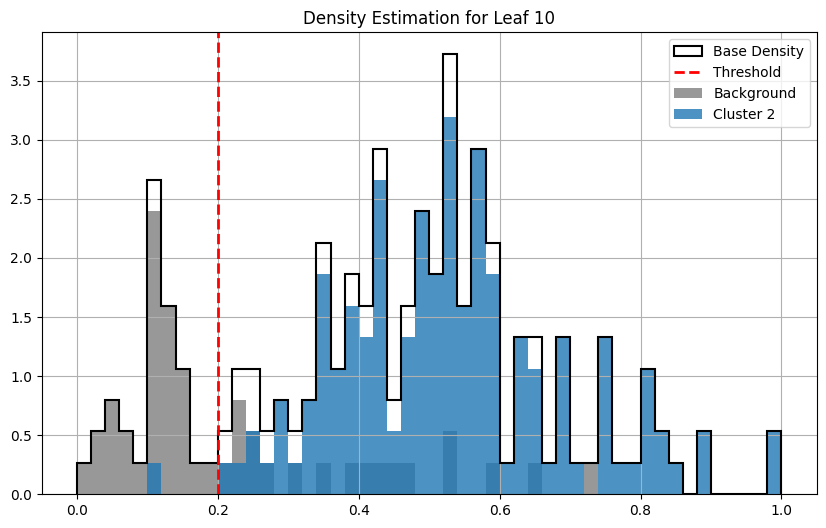

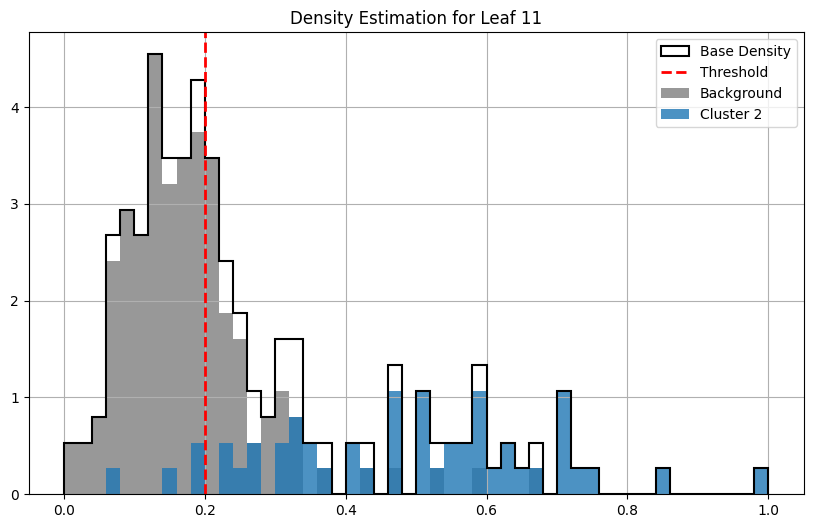

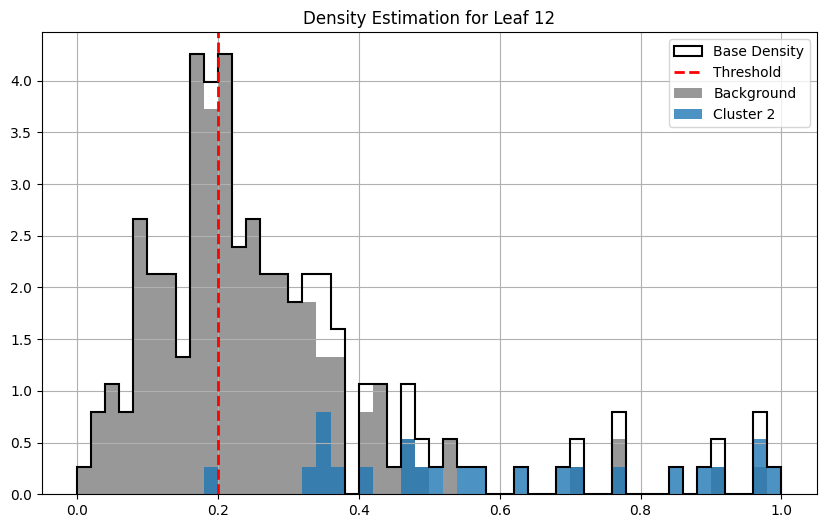

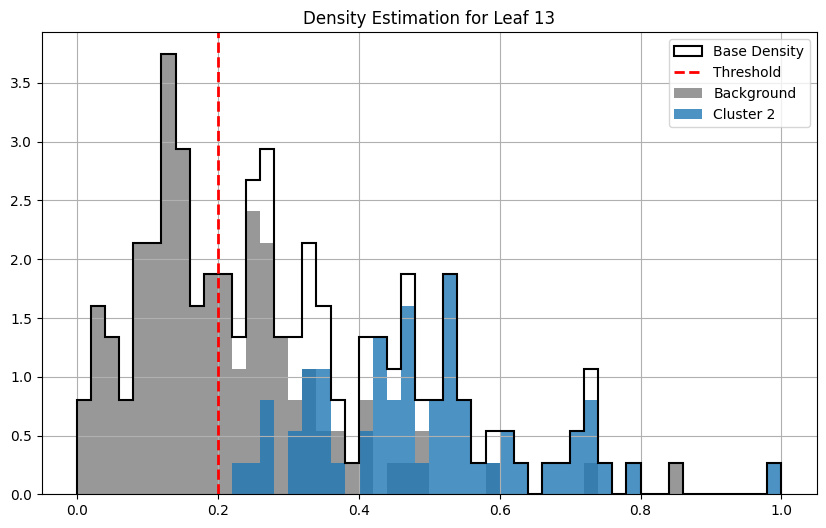

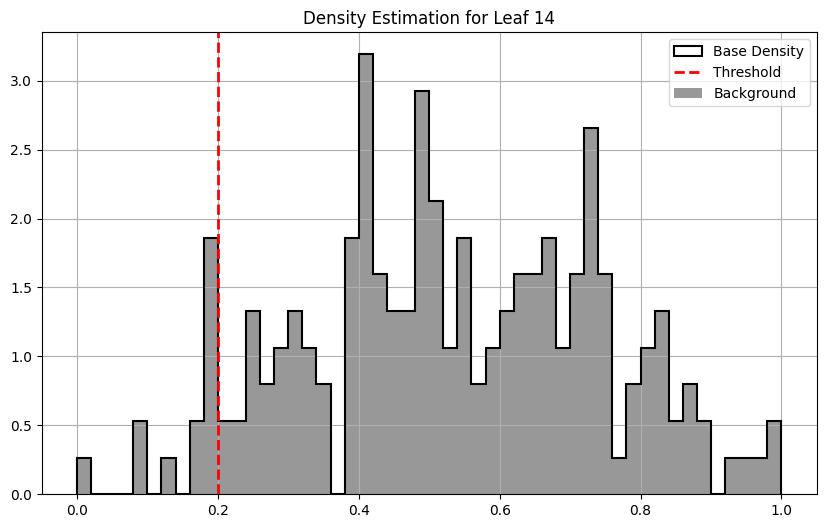

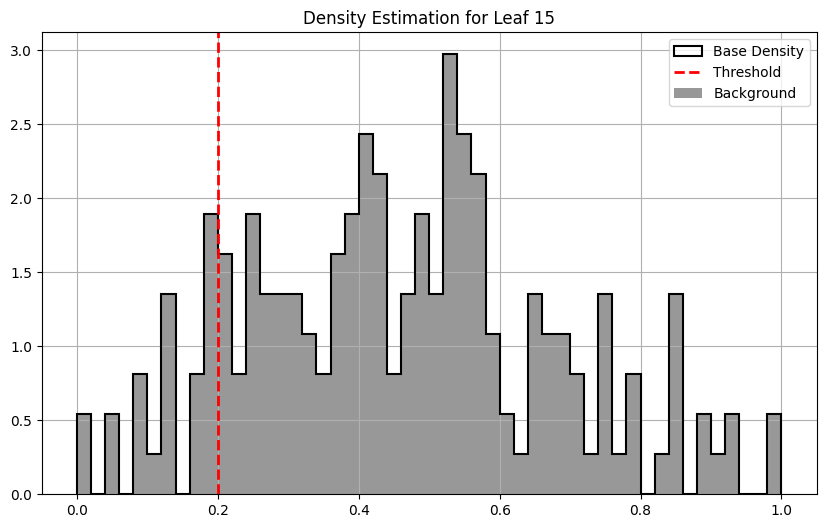

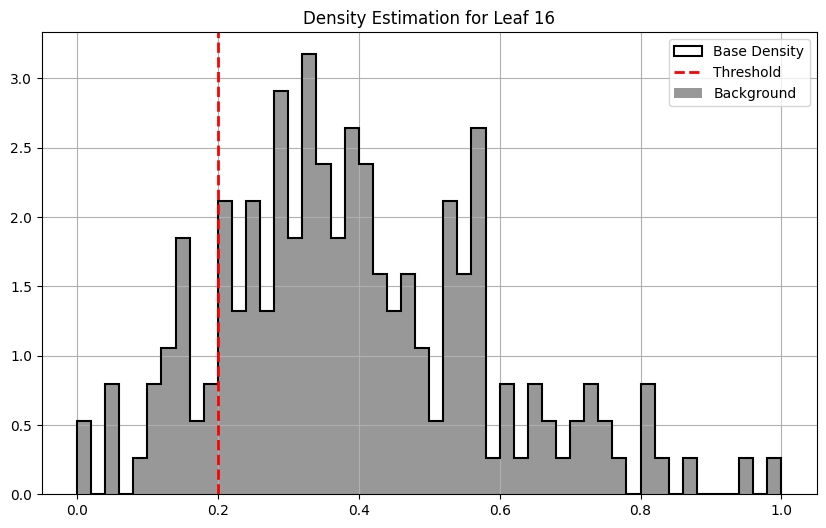

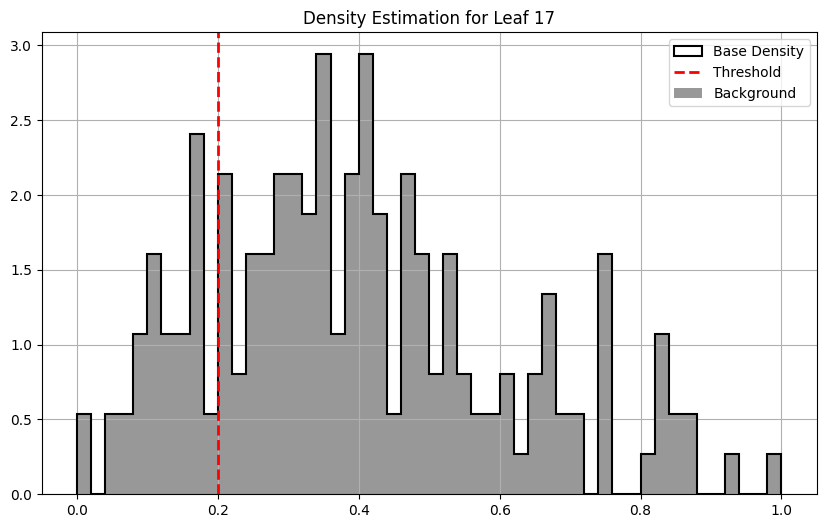

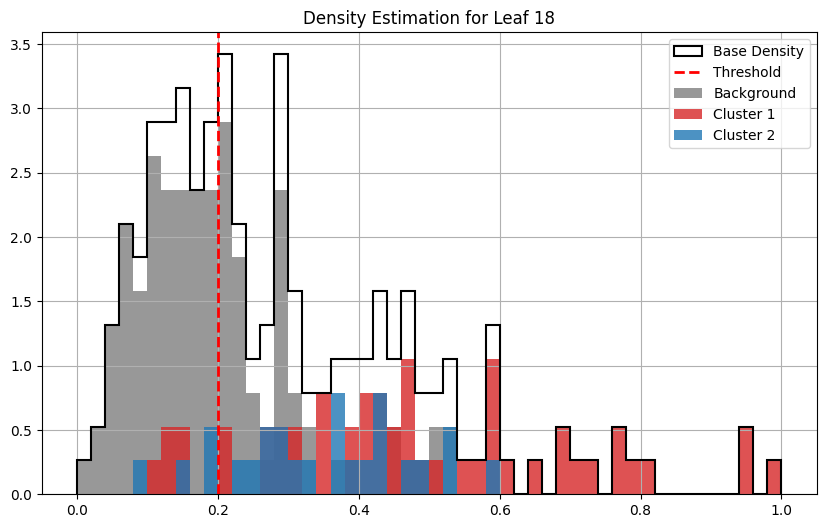

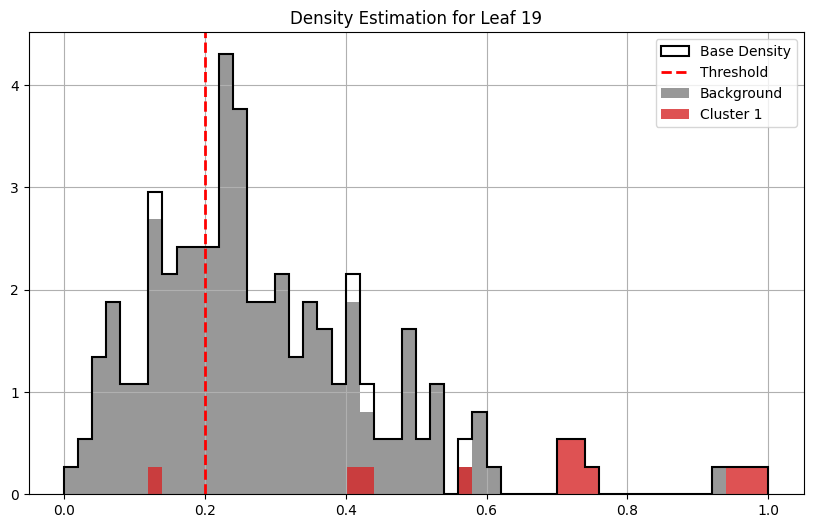

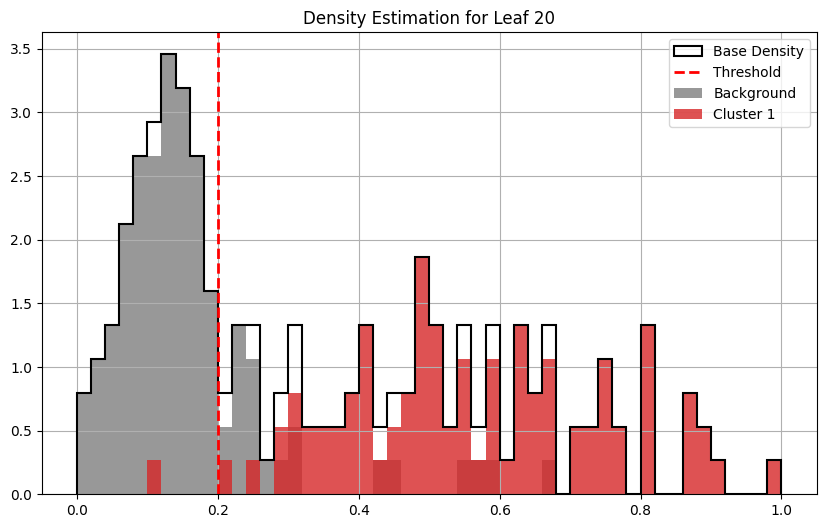

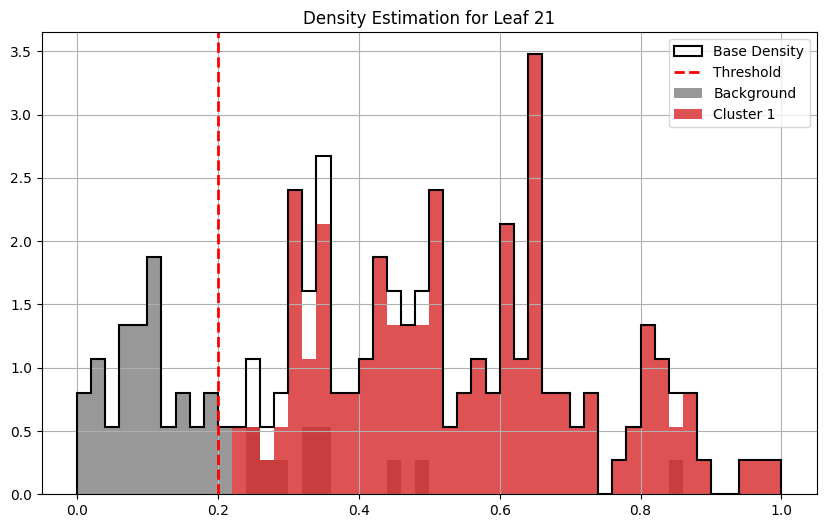

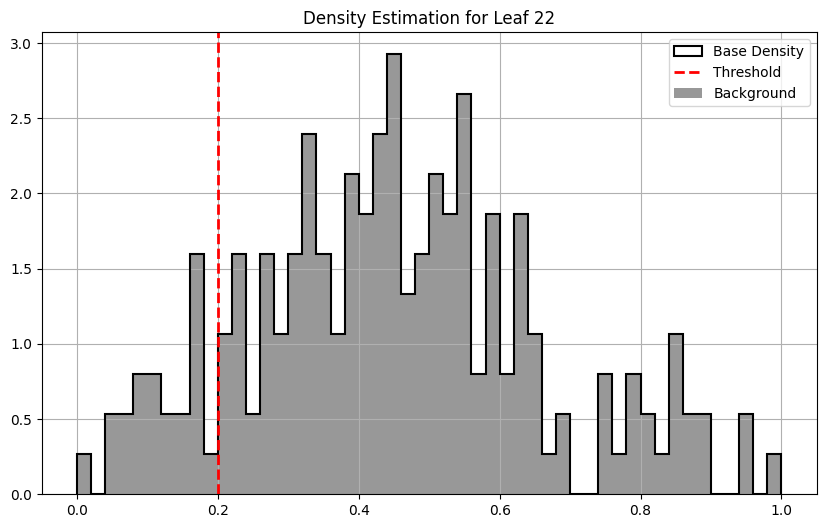

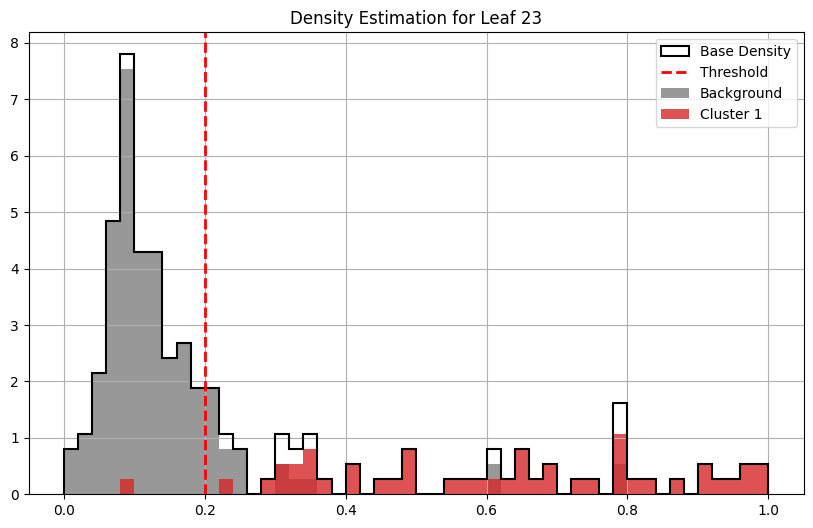

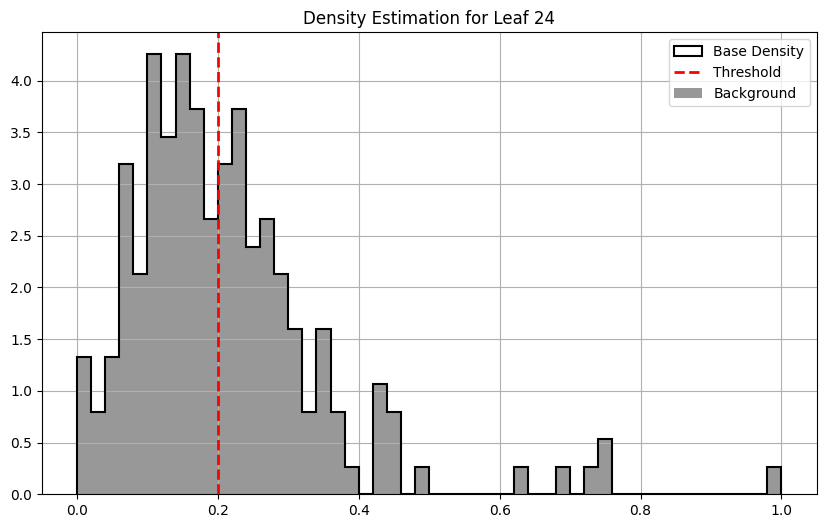

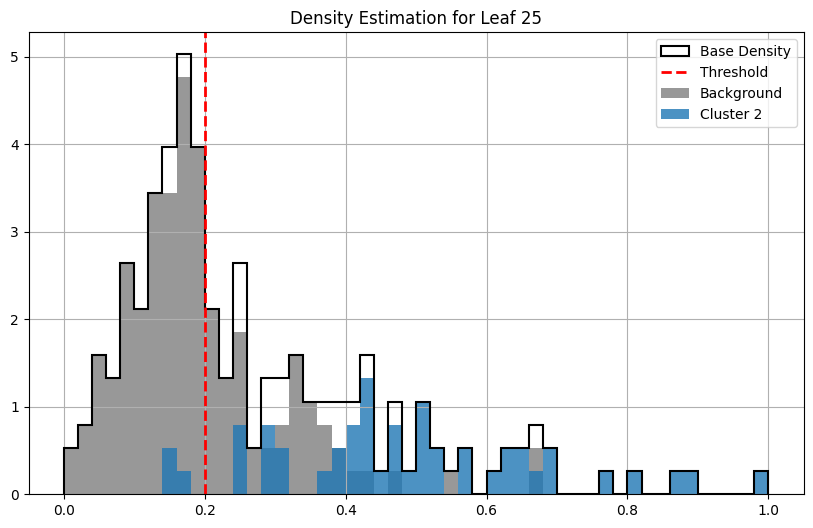

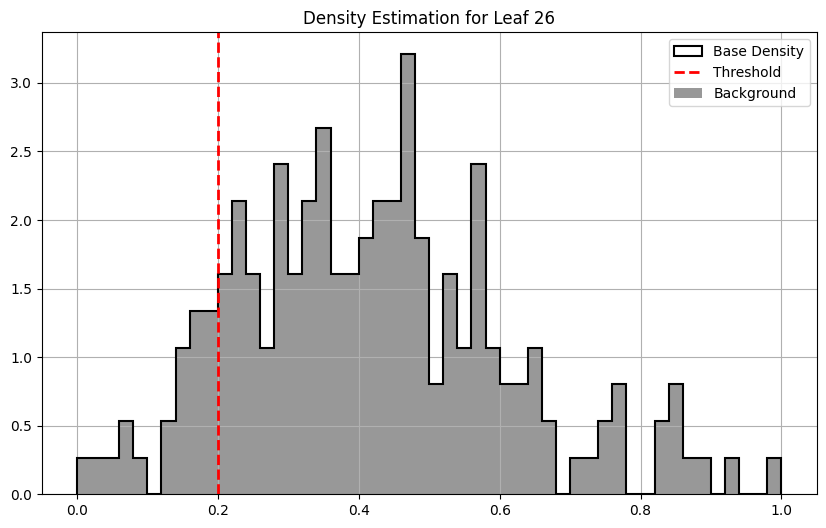

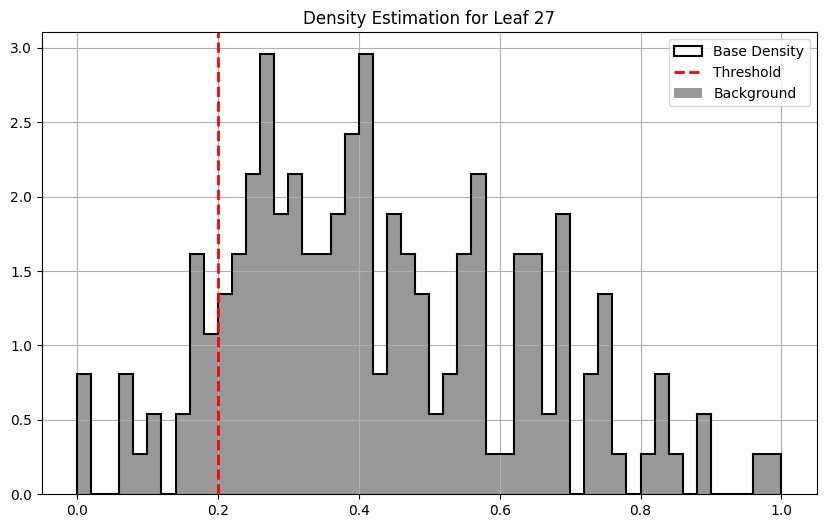

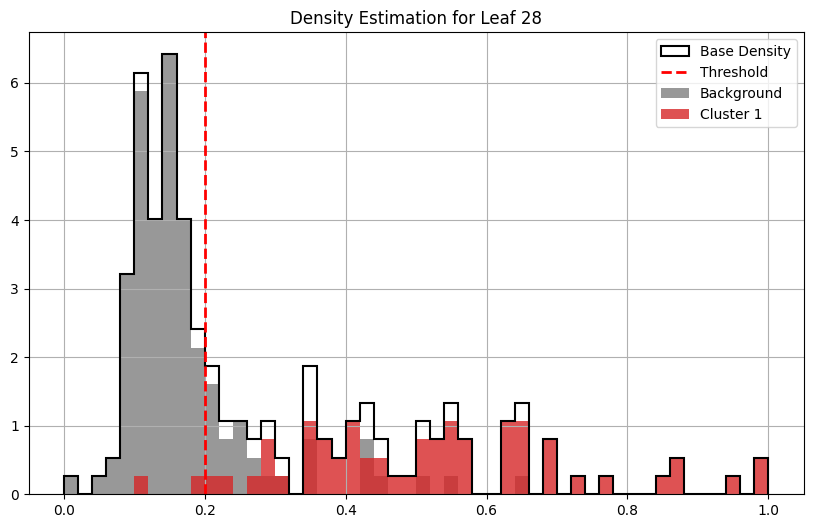

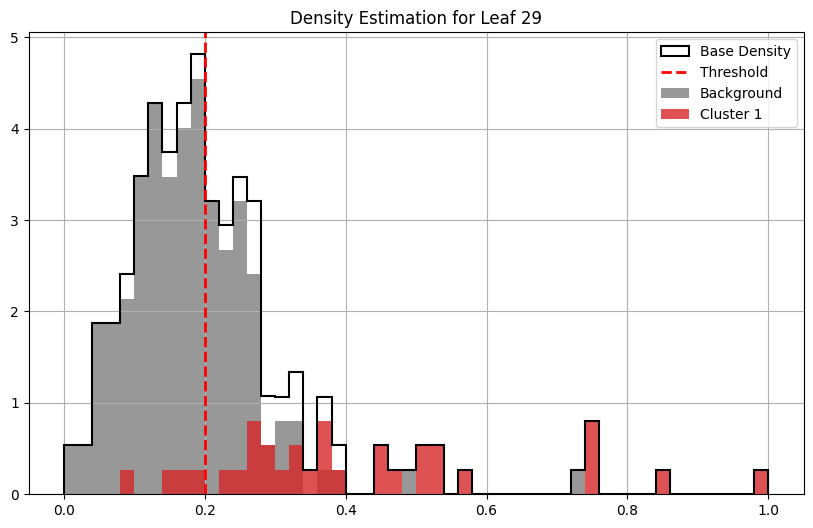

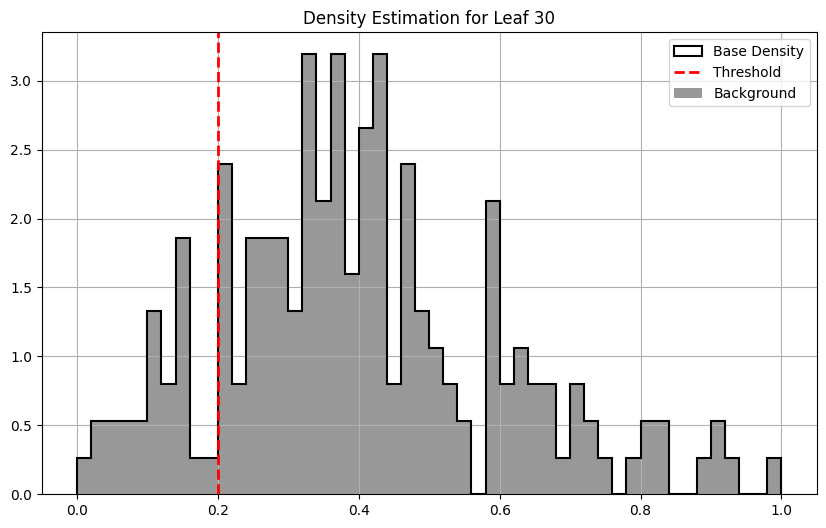

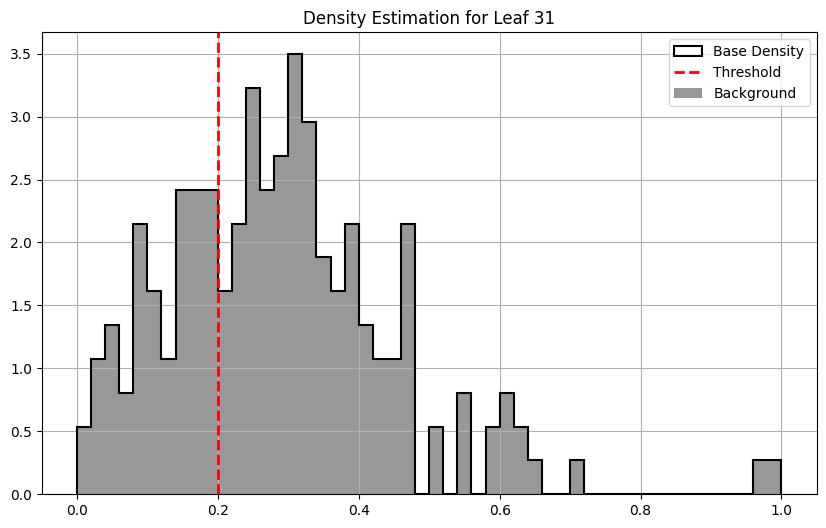

Execution time (softmax): 0 minutes, 0 seconds and 9 ms
Number of iterations (softmax): 156
Execution time (softmax): 0 minutes, 0 seconds and 8 ms
Number of iterations (softmax): 138
Execution time (softmax): 0 minutes, 0 seconds and 10 ms
Number of iterations (softmax): 171
Execution time (softmax): 0 minutes, 0 seconds and 11 ms
Number of iterations (softmax): 184
Execution time (softmax): 0 minutes, 0 seconds and 15 ms
Number of iterations (softmax): 250
Execution time (softmax): 0 minutes, 0 seconds and 13 ms
Number of iterations (softmax): 220
Execution time (softmax): 0 minutes, 0 seconds and 10 ms
Number of iterations (softmax): 183
Execution time (softmax): 0 minutes, 0 seconds and 14 ms
Number of iterations (softmax): 250
Execution time (softmax): 0 minutes, 0 seconds and 14 ms
Number of iterations (softmax): 250
Execution time (softmax): 0 minutes, 0 seconds and 14 ms
Number of iterations (softmax): 250
Execution time (softmax): 0 minutes, 0 seconds and 14 ms
Number of itera

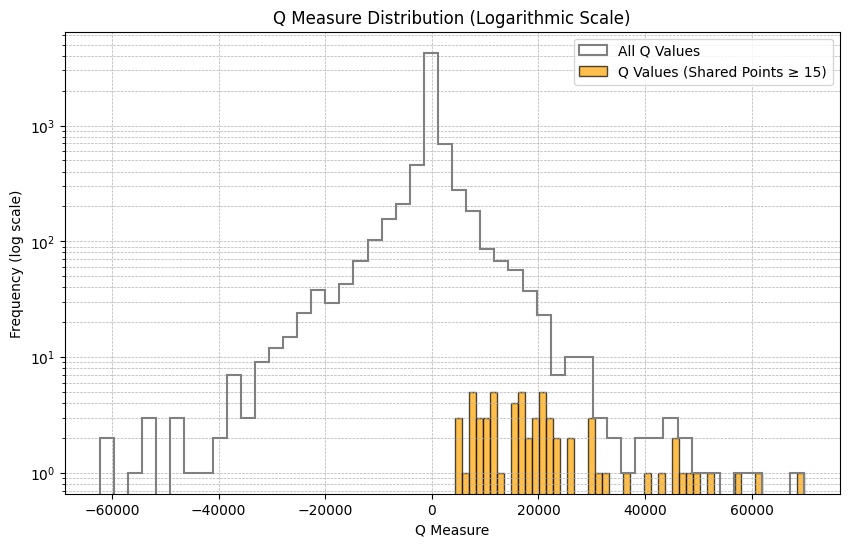

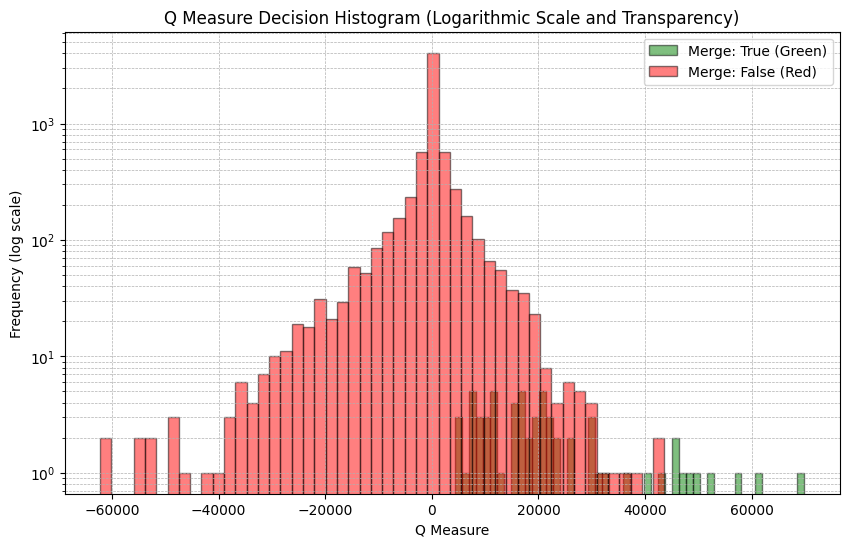

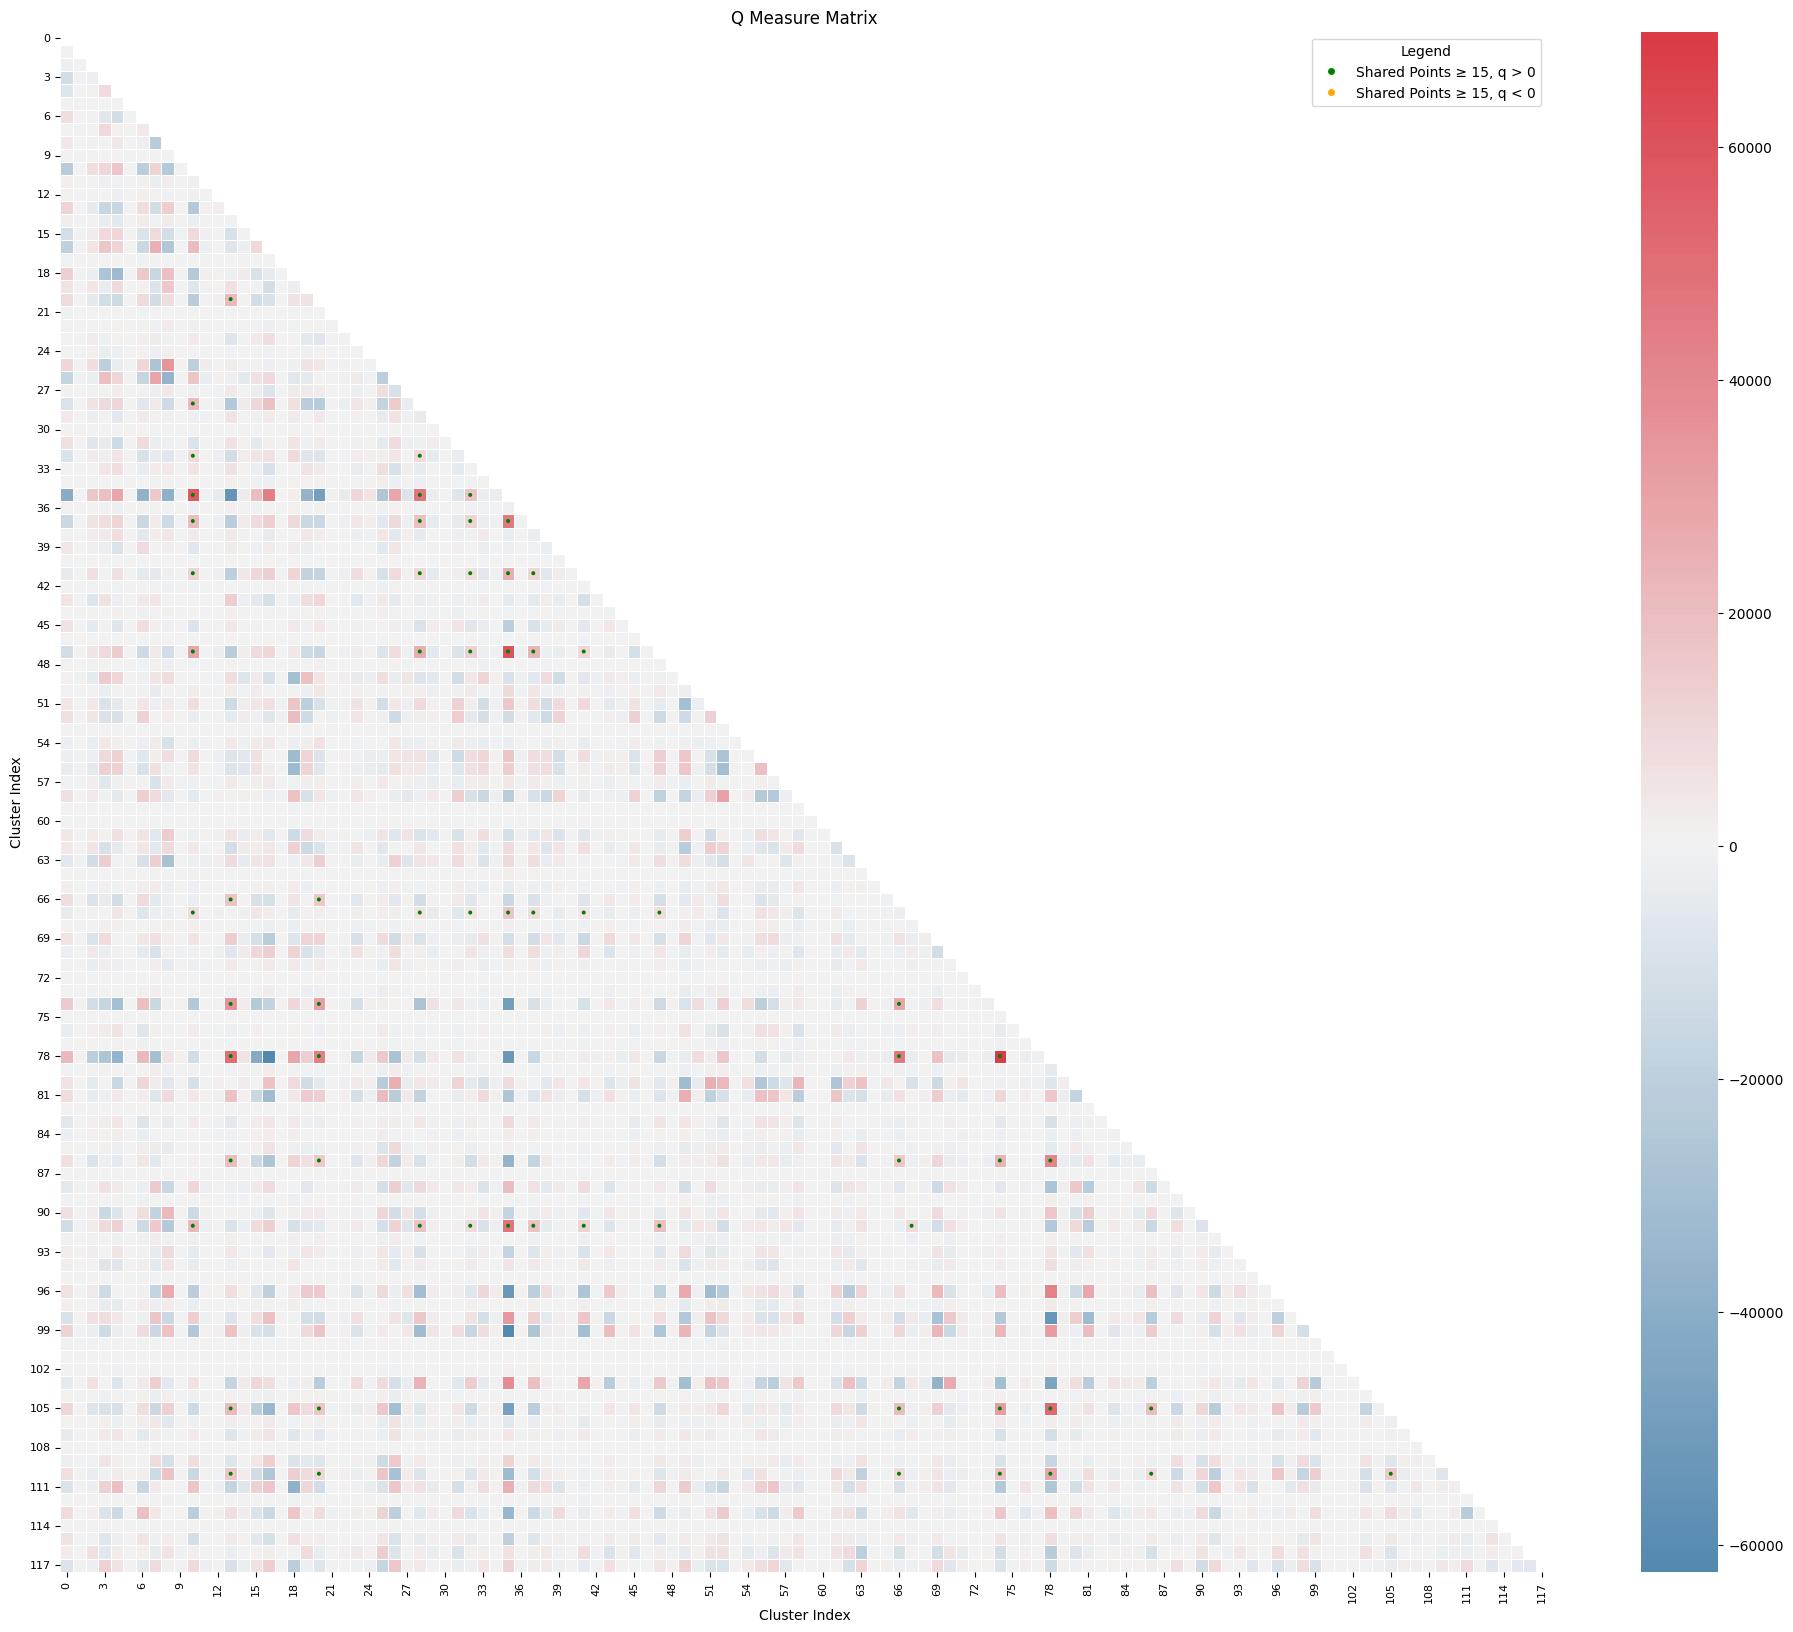

Hierarchical agglomerative merging with weights
Merging cluster 74 with cluster 78, Q = 69895.28714257063
Merging cluster 13 with cluster 74, Q = 76976.00291533717
Merging cluster 13 with cluster 105, Q = 98693.60580998965
Merging cluster 13 with cluster 66, Q = 99995.60296437264
Merging cluster 13 with cluster 86, Q = 112950.37955118385
Merging cluster 13 with cluster 20, Q = 123424.08725046909
Merging cluster 13 with cluster 99, Q = 115999.11126096986
Merging cluster 13 with cluster 96, Q = 113707.4348433503
Merging cluster 13 with cluster 81, Q = 126661.97713047628
Merging cluster 13 with cluster 69, Q = 137207.60156384332
Merging cluster 13 with cluster 110, Q = 136361.30184135766
Merging cluster 8 with cluster 13, Q = 124323.52447941827
Merging cluster 8 with cluster 25, Q = 142846.04163587347
Merging cluster 8 with cluster 19, Q = 122160.61176366884
Merging cluster 8 with cluster 49, Q = 131925.04081616987
Merging cluster 8 with cluster 90, Q = 126963.88282146942
Merging cluster 

In [17]:
final_clusters = tree_merging_clustering_with_weights(
    df, dist_v_opt, K=6, node_indices=node_indices, point_in_node=point_in_node, labels=labels,
    cluster_colors=colors, threshold=0.2, method="knn", bandwidth=0.5, max_neighbors=5,
    min_neighbors=5, color_option="clusters", single_color="tab:blue", option="before_softmax",  softmax_clustering_func=softmax_clustering_optimized_iphd 
)

In [18]:
cluster_labels = np.zeros(len(df), dtype=int) - 1  
for i, cluster in enumerate(final_clusters):
    for index in cluster:
        cluster_labels[index] = i
num_clusters = len(np.unique(cluster_labels))

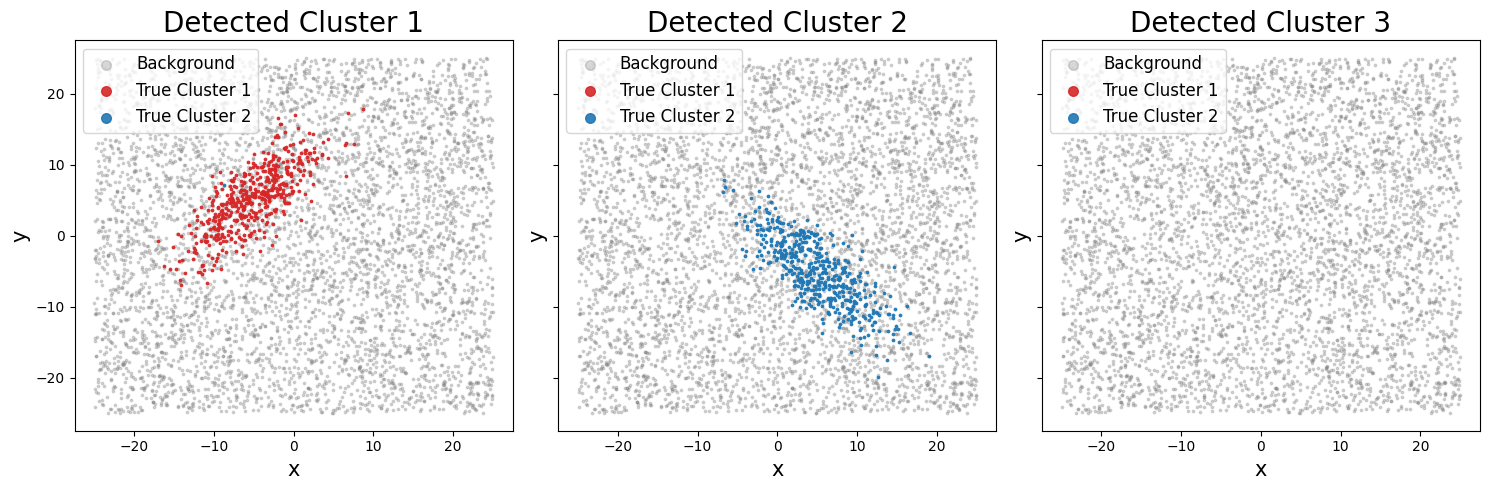

In [19]:
visualisations.visualise_cluster_result(
    df=df,
    cluster_labels=cluster_labels,
    true_labels=labels,
    K=num_clusters,  
    x_col='x',
    y_col='y',
    colors=colors,  
    alphas=alphas,  
    zorders=zorders  
)